In [1]:
# ============================================================
# Imports
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Load Feature-Engineered Dataset
# ============================================================

df = pd.read_csv(
    "../data/processed/freight_model_features.csv"
)

df["date"] = pd.to_datetime(df["date"])

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["date"].min(),
    "to",
    df["date"].max()
)

display(df.head())

Dataset shape: (167, 46)
Date range: 2011-02-01 00:00:00 to 2024-12-01 00:00:00


,date,bulk_carrier_handysize_usd_day,baltic_dry_index,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct,year_month,brent_price,...,wti_price_lag_1,wti_price_lag_3,dxy_index_lag_1,dxy_index_lag_3,vix_lag_1,vix_lag_3,gpr_index_lag_1,gpr_index_lag_3,thermal_coal_price_lag_1,thermal_coal_price_lag_3
0,2011-02-01,14358,2123,27476,0.80,0.905,2.91,23.26,2011-02,103.942105,...,89.578500,84.314762,79.146000,78.375715,17.315500,20.095714,97.203896,94.705170,91.493790,91.401032
1,2011-03-01,13963,2169,32091,1.23,0.914,2.17,11.21,2011-03,114.656087,...,89.743158,89.233182,77.782632,80.049091,17.430000,17.569546,90.014488,97.203896,86.159055,90.847361
2,2011-04-01,3000,1990,28063,0.53,0.920,-8.25,6.52,2011-04,122.964500,...,102.981305,89.578500,76.289566,79.146000,20.723478,17.315500,136.888306,97.203896,86.267639,91.493790
3,2011-05-01,10063,2075,35964,1.33,0.918,4.27,-8.66,2011-05,114.514286,...,110.038501,89.743158,74.724500,77.782632,16.244000,17.430000,91.017769,90.014488,86.461648,86.159055
4,2011-06-01,11561,2050,16981,1.00,0.877,-1.20,20.26,2011-06,113.901818,...,101.356667,102.981305,74.941428,76.289566,16.911429,20.723478,91.017769,136.888306,84.756273,86.267639


In [3]:
# ============================================================
# Define Target
# ============================================================

target = "bulk_carrier_handysize_usd_day"

print("Target:", target)

print(
    "Target range:",
    df[target].min(),
    "to",
    df[target].max()
)

Target: bulk_carrier_handysize_usd_day
Target range: 3000 to 21829


In [4]:
# ============================================================
#  Define Features
# ============================================================

features = [
    # Historical freight
    "freight_lag_1",
    "freight_lag_3",
    "freight_lag_6",
    "freight_lag_12",

    # Rolling freight behavior
    "freight_rolling_mean_3",
    "freight_rolling_mean_6",
    "freight_rolling_mean_12",
    "freight_rolling_std_3",

    # Market indicators
    "baltic_dry_index_lag_1",
    "baltic_dry_index_lag_3",

    "brent_price_lag_1",
    "brent_price_lag_3",

    "wti_price_lag_1",
    "wti_price_lag_3",

    "dxy_index_lag_1",
    "dxy_index_lag_3",

    "vix_lag_1",
    "vix_lag_3",

    "gpr_index_lag_1",
    "gpr_index_lag_3",

    "thermal_coal_price_lag_1",
    "thermal_coal_price_lag_3",

    # Seasonality
    "month_num",
    "quarter",
    "month_sin",
    "month_cos"
]

print("Number of features:", len(features))

print("\nFeatures:")
for feature in features:
    print(" -", feature)

Number of features: 26

Features:
 - freight_lag_1
 - freight_lag_3
 - freight_lag_6
 - freight_lag_12
 - freight_rolling_mean_3
 - freight_rolling_mean_6
 - freight_rolling_mean_12
 - freight_rolling_std_3
 - baltic_dry_index_lag_1
 - baltic_dry_index_lag_3
 - brent_price_lag_1
 - brent_price_lag_3
 - wti_price_lag_1
 - wti_price_lag_3
 - dxy_index_lag_1
 - dxy_index_lag_3
 - vix_lag_1
 - vix_lag_3
 - gpr_index_lag_1
 - gpr_index_lag_3
 - thermal_coal_price_lag_1
 - thermal_coal_price_lag_3
 - month_num
 - quarter
 - month_sin
 - month_cos


In [5]:
# ============================================================
# Feature Validation
# ============================================================

missing_features = [
    feature
    for feature in features
    if feature not in df.columns
]

if len(missing_features) == 0:
    print("✓ All model features exist.")
else:
    print("Missing features:")
    print(missing_features)

✓ All model features exist.


In [6]:
# ============================================================
# Check Missing Values
# ============================================================

model_data = df[
    ["date", target] + features
].copy()

missing = model_data.isna().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("✓ No missing values in modeling data.")
else:
    print("Columns with missing values:")
    display(missing)

✓ No missing values in modeling data.


In [7]:
# ============================================================
# Chronological Split
# ============================================================

train = model_data[
    model_data["date"] < "2023-01-01"
].copy()

validation = model_data[
    (model_data["date"] >= "2023-01-01") &
    (model_data["date"] < "2024-01-01")
].copy()

test = model_data[
    model_data["date"] >= "2024-01-01"
].copy()

print("TRAIN:")
print(train["date"].min(), "→", train["date"].max())
print("Rows:", len(train))

print("\nVALIDATION:")
print(validation["date"].min(), "→", validation["date"].max())
print("Rows:", len(validation))

print("\nTEST:")
print(test["date"].min(), "→", test["date"].max())
print("Rows:", len(test))

TRAIN:
2011-02-01 00:00:00 → 2022-12-01 00:00:00
Rows: 143

VALIDATION:
2023-01-01 00:00:00 → 2023-12-01 00:00:00
Rows: 12

TEST:
2024-01-01 00:00:00 → 2024-12-01 00:00:00
Rows: 12


In [8]:
# ============================================================
# Prepare X and y
# ============================================================

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_val.shape)
print("y_validation:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (143, 26)
y_train: (143,)
X_validation: (12, 26)
y_validation: (12,)
X_test: (12, 26)
y_test: (12,)


In [9]:
# ============================================================
#  Naive Baseline
# ============================================================

y_pred_naive = test["freight_lag_1"]

naive_mae = mean_absolute_error(
    y_test,
    y_pred_naive
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_naive
    )
)

naive_mape = (
    np.mean(
        np.abs(
            (y_test - y_pred_naive) / y_test
        )
    ) * 100
)

print("NAIVE BASELINE")
print("MAE :", round(naive_mae, 2))
print("RMSE:", round(naive_rmse, 2))
print("MAPE:", round(naive_mape, 2), "%")

NAIVE BASELINE
MAE : 2802.67
RMSE: 4153.06
MAPE: 42.45 %


In [10]:
# ============================================================
# Linear Regression
# ============================================================

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

linear_mape = (
    np.mean(
        np.abs(
            (y_test - y_pred_linear) / y_test
        )
    ) * 100
)

print("LINEAR REGRESSION")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("MAPE:", round(linear_mape, 2), "%")

LINEAR REGRESSION
MAE : 2668.26
RMSE: 3586.36
MAPE: 41.62 %


In [11]:
# ============================================================
#  Random Forest
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

rf_mape = (
    np.mean(
        np.abs(
            (y_test - y_pred_rf) / y_test
        )
    ) * 100
)

print("RANDOM FOREST")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("MAPE:", round(rf_mape, 2), "%")

RANDOM FOREST
MAE : 2375.48
RMSE: 3063.58
MAPE: 33.88 %


In [12]:
# ============================================================
#  XGBoost
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

xgb_mape = (
    np.mean(
        np.abs(
            (y_test - y_pred_xgb) / y_test
        )
    ) * 100
)

print("XGBOOST")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("MAPE:", round(xgb_mape, 2), "%")

XGBOOST
MAE : 2618.78
RMSE: 3478.28
MAPE: 36.09 %


In [13]:
# ============================================================
#  Model Comparison
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        naive_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        naive_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAPE (%)": [
        naive_mape,
        linear_mape,
        rf_mape,
        xgb_mape
    ]
})

results = results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    results.round(2)
)

,Model,MAE,RMSE,MAPE (%)
0,Random Forest,2375.48,3063.58,33.88
1,XGBoost,2618.78,3478.28,36.09
2,Linear Regression,2668.26,3586.36,41.62
3,Naive Baseline,2802.67,4153.06,42.45


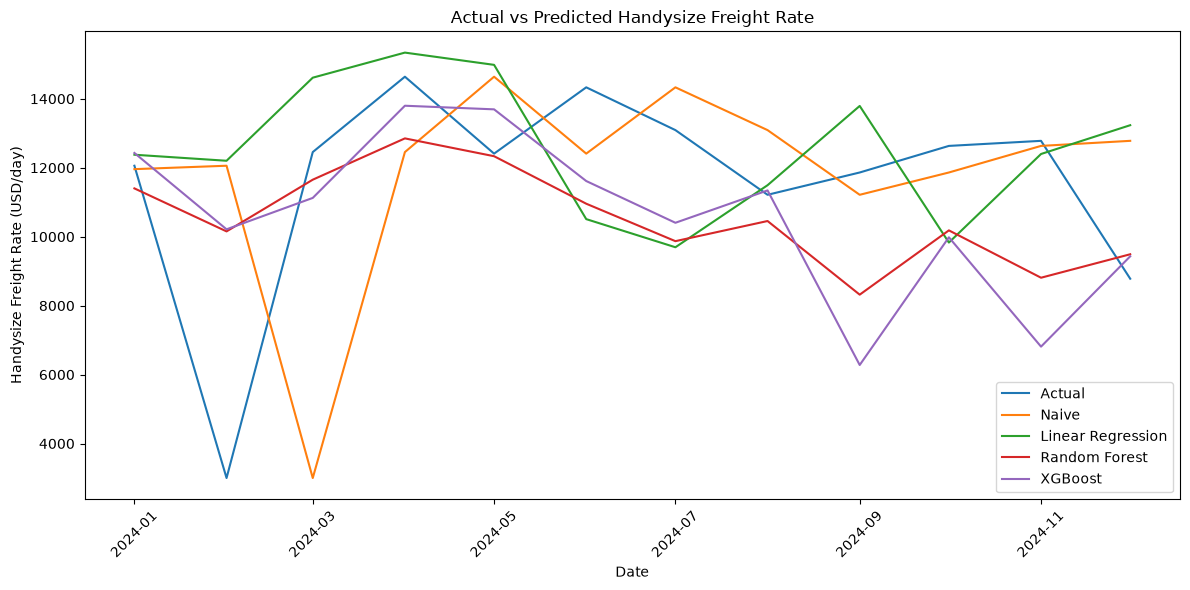

In [14]:
# ============================================================
#  Actual vs Predicted Freight
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    y_pred_naive,
    label="Naive"
)

plt.plot(
    test["date"],
    y_pred_linear,
    label="Linear Regression"
)

plt.plot(
    test["date"],
    y_pred_rf,
    label="Random Forest"
)

plt.plot(
    test["date"],
    y_pred_xgb,
    label="XGBoost"
)

plt.xlabel("Date")
plt.ylabel("Handysize Freight Rate (USD/day)")
plt.title("Actual vs Predicted Handysize Freight Rate")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
# ============================================================
# XGBoost Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(
    importance.head(15)
)

,Feature,Importance
8,baltic_dry_index_lag_1,0.099608
9,baltic_dry_index_lag_3,0.079533
5,freight_rolling_mean_6,0.068871
11,brent_price_lag_3,0.053170
21,thermal_coal_price_lag_3,0.052689
4,freight_rolling_mean_3,0.049961
2,freight_lag_6,0.047971
16,vix_lag_1,0.044428
7,freight_rolling_std_3,0.042040
10,brent_price_lag_1,0.040860


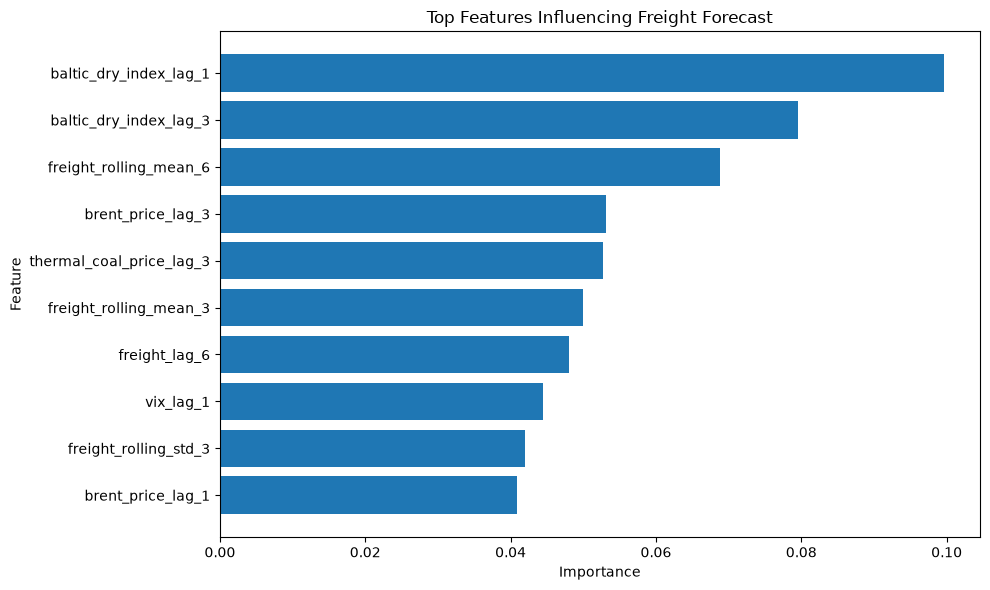

In [16]:
top_features = importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing Freight Forecast")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
#  Validation Evaluation
# ============================================================

# Linear Regression
y_pred_linear_val = linear_model.predict(X_val)

# Random Forest
y_pred_rf_val = rf_model.predict(X_val)

# XGBoost
y_pred_xgb_val = xgb_model.predict(X_val)

# Naive baseline
y_pred_naive_val = validation["freight_lag_1"]


def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred) / y_true
            )
        ) * 100
    )

    return mae, rmse, mape


validation_results = []

for name, predictions in [
    ("Naive Baseline", y_pred_naive_val),
    ("Linear Regression", y_pred_linear_val),
    ("Random Forest", y_pred_rf_val),
    ("XGBoost", y_pred_xgb_val)
]:

    mae, rmse, mape = calculate_metrics(
        y_val,
        predictions
    )

    validation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })


validation_results = pd.DataFrame(
    validation_results
)

validation_results = validation_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    validation_results.round(2)
)

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,3723.07,4653.88,38.27
1,Random Forest,3766.76,4797.82,47.11
2,XGBoost,3935.35,4881.17,51.12
3,Naive Baseline,5315.83,6190.63,59.50


In [18]:
# ============================================================
#  Random Forest Hyperparameter Testing
# ============================================================

rf_configs = [
    {
        "n_estimators": 200,
        "max_depth": 4,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 300,
        "max_depth": 6,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 500,
        "max_depth": 8,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 3
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 2
    }
]

rf_validation_results = []

for config in rf_configs:

    model = RandomForestRegressor(
        **config,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    mae, rmse, mape = calculate_metrics(
        y_val,
        predictions
    )

    rf_validation_results.append({
        **config,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })


rf_validation_results = pd.DataFrame(
    rf_validation_results
)

rf_validation_results = rf_validation_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    rf_validation_results.round(2)
)

,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,MAPE (%)
0,200,4.0,2,3609.36,4723.89,44.64
1,500,NaN,2,3668.27,4731.75,46.94
2,500,8.0,2,3686.52,4773.19,47.02
3,300,10.0,3,3766.61,4759.78,47.04
4,300,6.0,2,3766.76,4797.82,47.11


In [19]:
# ============================================================
# XGBoost Hyperparameter Testing
# ============================================================

xgb_configs = [
    {
        "n_estimators": 200,
        "max_depth": 2,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.02
    },
    {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.02
    }
]

xgb_validation_results = []

for config in xgb_configs:

    model = XGBRegressor(
        **config,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    mae, rmse, mape = calculate_metrics(
        y_val,
        predictions
    )

    xgb_validation_results.append({
        **config,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })


xgb_validation_results = pd.DataFrame(
    xgb_validation_results
)

xgb_validation_results = xgb_validation_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    xgb_validation_results.round(2)
)

,n_estimators,max_depth,learning_rate,MAE,RMSE,MAPE (%)
0,200,2,0.03,3607.64,4676.49,46.02
1,300,3,0.03,3935.35,4881.17,51.12
2,300,4,0.02,3984.42,4921.25,51.42
3,500,3,0.03,4106.40,5058.80,53.62
4,500,4,0.02,4106.89,5036.63,53.21


In [20]:
# ============================================================
#  Best Hyperparameters
# ============================================================

best_rf = rf_validation_results.iloc[0]

best_xgb = xgb_validation_results.iloc[0]

print("BEST RANDOM FOREST")
display(best_rf.to_frame().T)

print("\nBEST XGBOOST")
display(best_xgb.to_frame().T)

BEST RANDOM FOREST


,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,MAPE (%)
0,200.0,4.0,2.0,3609.355592,4723.890142,44.642539



BEST XGBOOST


,n_estimators,max_depth,learning_rate,MAE,RMSE,MAPE (%)
0,200.0,2.0,0.03,3607.642578,4676.490565,46.021346


In [21]:
# ============================================================
# Select Final Model
# ============================================================

if best_rf["MAE"] <= best_xgb["MAE"]:
    selected_model_name = "Random Forest"
    selected_model_config = best_rf

else:
    selected_model_name = "XGBoost"
    selected_model_config = best_xgb


print("Selected model:", selected_model_name)

Selected model: XGBoost


In [22]:
# ============================================================
#  Combine Training + Validation Data
# ============================================================

train_validation = pd.concat(
    [train, validation],
    axis=0
).sort_values("date").reset_index(drop=True)

X_train_final = train_validation[features]
y_train_final = train_validation[target]

X_test_final = test[features]
y_test_final = test[target]

print("Final training observations:", len(train_validation))
print(
    "Training period:",
    train_validation["date"].min(),
    "to",
    train_validation["date"].max()
)

print("\nFinal test observations:", len(test))
print(
    "Test period:",
    test["date"].min(),
    "to",
    test["date"].max()
)

Final training observations: 155
Training period: 2011-02-01 00:00:00 to 2023-12-01 00:00:00

Final test observations: 12
Test period: 2024-01-01 00:00:00 to 2024-12-01 00:00:00


In [23]:
# ============================================================
#  Final XGBoost Model
# ============================================================

final_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

final_xgb.fit(
    X_train_final,
    y_train_final
)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


In [24]:
# ============================================================
#  Final Test Predictions
# ============================================================

y_pred_final = final_xgb.predict(
    X_test_final
)

print("Predictions generated.")

display(
    pd.DataFrame({
        "Date": test["date"].values,
        "Actual": y_test_final.values,
        "Predicted": y_pred_final
    })
)

Predictions generated.


,Date,Actual,Predicted
0,2024-01-01,12058,13243.160156
1,2024-02-01,3000,12100.928711
2,2024-03-01,12454,12879.671875
3,2024-04-01,14640,14237.644531
4,2024-05-01,12409,12789.230469
5,2024-06-01,14332,12833.359375
6,2024-07-01,13091,11191.146484
7,2024-08-01,11215,12001.767578
8,2024-09-01,11862,9193.513672
9,2024-10-01,12633,11088.411133


In [25]:
# ============================================================
# Final Test Metrics
# ============================================================

final_mae = mean_absolute_error(
    y_test_final,
    y_pred_final
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        y_pred_final
    )
)

final_mape = (
    np.mean(
        np.abs(
            (y_test_final - y_pred_final)
            / y_test_final
        )
    ) * 100
)

print("========================================")
print("FINAL XGBOOST TEST PERFORMANCE")
print("========================================")

print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("MAPE:", round(final_mape, 2), "%")

FINAL XGBOOST TEST PERFORMANCE
MAE : 2117.82
RMSE: 3111.19
MAPE: 36.75 %


In [26]:
# ============================================================
#Final Model vs Naive Baseline
# ============================================================

final_naive_pred = test["freight_lag_1"]

final_naive_mae = mean_absolute_error(
    y_test_final,
    final_naive_pred
)

final_naive_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_naive_pred
    )
)

final_naive_mape = (
    np.mean(
        np.abs(
            (y_test_final - final_naive_pred)
            / y_test_final
        )
    ) * 100
)

final_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Final XGBoost"
    ],
    "MAE": [
        final_naive_mae,
        final_mae
    ],
    "RMSE": [
        final_naive_rmse,
        final_rmse
    ],
    "MAPE (%)": [
        final_naive_mape,
        final_mape
    ]
})

display(
    final_comparison.round(2)
)

,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,2802.67,4153.06,42.45
1,Final XGBoost,2117.82,3111.19,36.75


In [27]:
# ============================================================
#  Improvement Over Baseline
# ============================================================

mae_improvement = (
    (final_naive_mae - final_mae)
    / final_naive_mae
) * 100

rmse_improvement = (
    (final_naive_rmse - final_rmse)
    / final_naive_rmse
) * 100

print(
    "MAE improvement over naive baseline:",
    round(mae_improvement, 2),
    "%"
)

print(
    "RMSE improvement over naive baseline:",
    round(rmse_improvement, 2),
    "%"
)

MAE improvement over naive baseline: 24.44 %
RMSE improvement over naive baseline: 25.09 %


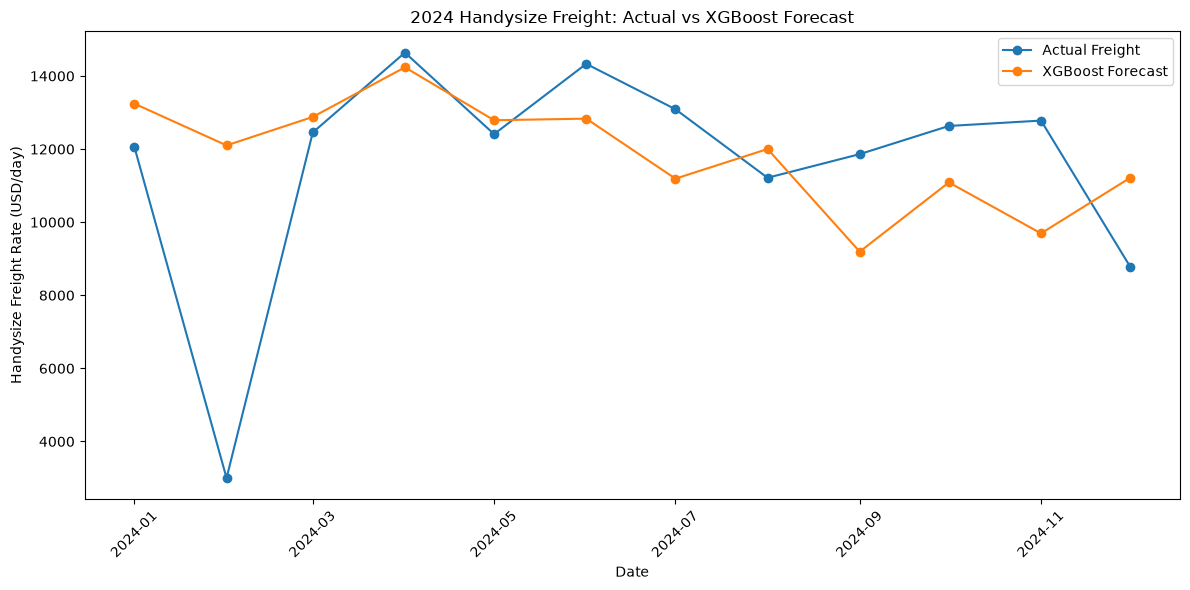

In [28]:
# ============================================================
#  Actual vs Predicted
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test_final,
    marker="o",
    label="Actual Freight"
)

plt.plot(
    test["date"],
    y_pred_final,
    marker="o",
    label="XGBoost Forecast"
)

plt.xlabel("Date")
plt.ylabel("Handysize Freight Rate (USD/day)")
plt.title(
    "2024 Handysize Freight: Actual vs XGBoost Forecast"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [29]:
# ============================================================
#  Forecast Output Table
# ============================================================

forecast_results = pd.DataFrame({
    "date": test["date"].values,
    "actual_freight": y_test_final.values,
    "predicted_freight": y_pred_final
})

forecast_results["absolute_error"] = (
    np.abs(
        forecast_results["actual_freight"]
        - forecast_results["predicted_freight"]
    )
)

display(forecast_results.round(2))

C:\Users\saibr\AppData\Local\Temp\ipykernel_2508\605620840.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(forecast_results.round(2))


,date,actual_freight,predicted_freight,absolute_error
0,2024-01-01,12058,13243.160156,1185.16
1,2024-02-01,3000,12100.929688,9100.93
2,2024-03-01,12454,12879.669922,425.67
3,2024-04-01,14640,14237.639648,402.36
4,2024-05-01,12409,12789.230469,380.23
5,2024-06-01,14332,12833.360352,1498.64
6,2024-07-01,13091,11191.150391,1899.85
7,2024-08-01,11215,12001.769531,786.77
8,2024-09-01,11862,9193.509766,2668.49
9,2024-10-01,12633,11088.410156,1544.59


In [30]:
# ============================================================
#  Final XGBoost Feature Importance
# ============================================================

final_importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_xgb.feature_importances_
})

final_importance = final_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    final_importance.head(15)
)

,Feature,Importance
0,baltic_dry_index_lag_1,0.121091
1,thermal_coal_price_lag_3,0.068441
2,baltic_dry_index_lag_3,0.065697
3,freight_rolling_mean_6,0.057028
4,brent_price_lag_3,0.046332
5,freight_rolling_mean_3,0.046317
6,vix_lag_1,0.042768
7,freight_rolling_std_3,0.042688
8,freight_lag_6,0.041490
9,wti_price_lag_1,0.041384


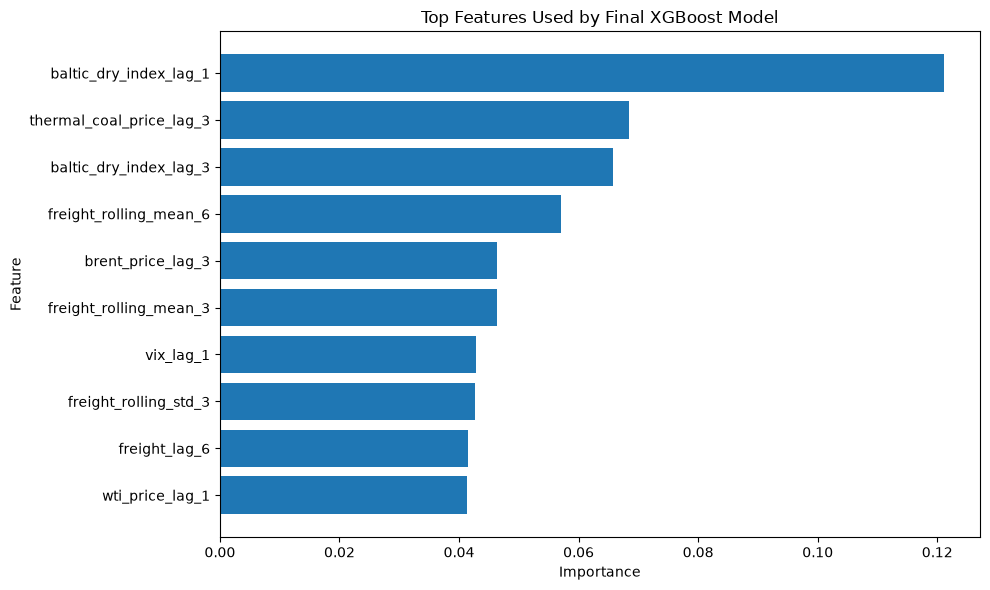

In [31]:
# ============================================================
# Feature Importance Graph
# ============================================================

top_features = (
    final_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Top Features Used by Final XGBoost Model"
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
#  Save Forecast Results
# ============================================================

forecast_output_path = (
    "../data/processed/final_freight_forecast_2024.csv"
)

forecast_results.to_csv(
    forecast_output_path,
    index=False
)

print("Saved:")
print(forecast_output_path)

Saved:
../data/processed/final_freight_forecast_2024.csv


In [33]:
# ============================================================
#  Save Final Model Metrics
# ============================================================

metrics_output = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Final XGBoost"
    ],
    "MAE": [
        final_naive_mae,
        final_mae
    ],
    "RMSE": [
        final_naive_rmse,
        final_rmse
    ],
    "MAPE (%)": [
        final_naive_mape,
        final_mape
    ]
})

metrics_path = (
    "../data/processed/final_model_metrics.csv"
)

metrics_output.to_csv(
    metrics_path,
    index=False
)

display(metrics_output.round(2))

print("Saved:")
print(metrics_path)

,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,2802.67,4153.06,42.45
1,Final XGBoost,2117.82,3111.19,36.75


Saved:
../data/processed/final_model_metrics.csv


In [34]:
# ============================================================
#  Prepare Latest Data for Next-Month Forecast
# ============================================================

latest = df.sort_values("date").iloc[-1]

print("Latest available month:")
print(latest["date"])

print("\nLatest freight rate:")
print(latest[target])

print("\nLatest market indicators:")
print("BDI:", latest["baltic_dry_index"])
print("Brent:", latest["brent_price"])
print("WTI:", latest["wti_price"])
print("Coal:", latest["thermal_coal_price"])
print("VIX:", latest["vix"])
print("GPR:", latest["gpr_index"])

Latest available month:
2024-12-01 00:00:00

Latest freight rate:
8781

Latest market indicators:
BDI: 2206
Brent: 73.12857164655414
WTI: 69.69761912027995
Coal: 121.74204090909092
VIX: 15.866190592447916
GPR: 128.90164184570312


In [35]:
# ============================================================
#  Build Next-Month Forecast Features
# ============================================================

latest_features = df.sort_values("date").iloc[-1].copy()

next_month = latest_features["date"] + pd.DateOffset(months=1)

forecast_input = latest_features[features].copy()

# Update seasonal variables for the forecast month
forecast_input["month_num"] = next_month.month
forecast_input["quarter"] = next_month.quarter

forecast_input["month_sin"] = np.sin(
    2 * np.pi * next_month.month / 12
)

forecast_input["month_cos"] = np.cos(
    2 * np.pi * next_month.month / 12
)

forecast_input = pd.DataFrame(
    [forecast_input],
    columns=features
)

print("Forecast month:", next_month)
print("Input shape:", forecast_input.shape)

display(forecast_input)

Forecast month: 2025-01-01 00:00:00
Input shape: (1, 26)


,freight_lag_1,freight_lag_3,freight_lag_6,freight_lag_12,freight_rolling_mean_3,freight_rolling_mean_6,freight_rolling_mean_12,freight_rolling_std_3,baltic_dry_index_lag_1,baltic_dry_index_lag_3,...,vix_lag_1,vix_lag_3,gpr_index_lag_1,gpr_index_lag_3,thermal_coal_price_lag_1,thermal_coal_price_lag_3,month_num,quarter,month_sin,month_cos
166,12780.0,11862.0,14332.0,11959.0,12425.0,12652.166667,11869.416667,493.081129,2071.0,1821.0,...,16.121,17.769,128.901642,140.975067,126.708114,130.688824,1,1,0.5,0.866025


In [36]:
# ============================================================
#  Next-Month Freight Forecast
# ============================================================

next_month_prediction = final_xgb.predict(
    forecast_input
)[0]

print("==========================================")
print("NEXT-MONTH FREIGHT FORECAST")
print("==========================================")

print(
    "Forecast month:",
    next_month.strftime("%Y-%m")
)

print(
    "Predicted Handysize freight rate:",
    round(next_month_prediction, 2),
    "USD/day"
)

NEXT-MONTH FREIGHT FORECAST
Forecast month: 2025-01
Predicted Handysize freight rate: 11070.68 USD/day


In [37]:
# ============================================================
#  Forecast vs Latest Freight
# ============================================================

latest_freight = latest[target]

forecast_change = (
    (next_month_prediction - latest_freight)
    / latest_freight
) * 100

print("Latest freight rate:",
      round(latest_freight, 2),
      "USD/day")

print("Next-month forecast:",
      round(next_month_prediction, 2),
      "USD/day")

print("Expected change:",
      round(forecast_change, 2),
      "%")

Latest freight rate: 8781 USD/day
Next-month forecast: 11070.68 USD/day
Expected change: 26.08 %


In [38]:
# ============================================================
# Market Direction Signal
# ============================================================

if forecast_change <= -5:
    market_signal = "FREIGHT EXPECTED TO FALL"

elif forecast_change >= 5:
    market_signal = "FREIGHT EXPECTED TO RISE"

else:
    market_signal = "FREIGHT EXPECTED TO REMAIN STABLE"

print("Market signal:", market_signal)

Market signal: FREIGHT EXPECTED TO RISE


In [39]:
# ============================================================
#  Forecast Output
# ============================================================

forecast_output = pd.DataFrame({
    "forecast_date": [next_month],
    "latest_freight_usd_day": [latest_freight],
    "predicted_freight_usd_day": [next_month_prediction],
    "expected_change_pct": [forecast_change],
    "market_signal": [market_signal]
})

display(
    forecast_output.round(2)
)

C:\Users\saibr\AppData\Local\Temp\ipykernel_2508\3785597174.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  forecast_output.round(2)


,forecast_date,latest_freight_usd_day,predicted_freight_usd_day,expected_change_pct,market_signal
0,2025-01-01,8781,11070.679688,26.08,FREIGHT EXPECTED TO RISE


In [40]:
# ============================================================
#  Save Next-Month Forecast
# ============================================================

next_month_forecast_path = (
    "../data/processed/next_month_freight_forecast.csv"
)

forecast_output.to_csv(
    next_month_forecast_path,
    index=False
)

print("Saved:")
print(next_month_forecast_path)

Saved:
../data/processed/next_month_freight_forecast.csv


In [41]:
# ============================================================
#  Save Final XGBoost Model
# ============================================================

import joblib

model_path = "../ml/forecasting/final_xgboost_model.joblib"

joblib.dump(
    final_xgb,
    model_path
)

print("Model saved:")
print(model_path)

Model saved:
../ml/forecasting/final_xgboost_model.joblib


In [42]:
# ============================================================
#  Save Feature List
# ============================================================

feature_config = pd.DataFrame({
    "feature": features
})

feature_config_path = (
    "../ml/forecasting/model_features.csv"
)

feature_config.to_csv(
    feature_config_path,
    index=False
)

print("Feature configuration saved:")
print(feature_config_path)

Feature configuration saved:
../ml/forecasting/model_features.csv


In [43]:
# ============================================================
#  Additional Forecast Metrics
# ============================================================

smape = (
    np.mean(
        2 * np.abs(y_test_final - y_pred_final)
        / (
            np.abs(y_test_final)
            + np.abs(y_pred_final)
            + 1e-8
        )
    )
    * 100
)

wape = (
    np.sum(
        np.abs(y_test_final - y_pred_final)
    )
    /
    np.sum(
        np.abs(y_test_final)
    )
) * 100

print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("MAPE:", round(final_mape, 2), "%")
print("sMAPE:", round(smape, 2), "%")
print("WAPE :", round(wape, 2), "%")

MAE : 2117.82
RMSE: 3111.19
MAPE: 36.75 %
sMAPE: 21.89 %
WAPE : 18.25 %


In [44]:
# ============================================================
#  Investigate Large Forecast Errors
# ============================================================

error_analysis = forecast_results.copy()

error_analysis["percentage_error"] = (
    np.abs(
        error_analysis["actual_freight"]
        - error_analysis["predicted_freight"]
    )
    / error_analysis["actual_freight"]
) * 100

display(
    error_analysis.sort_values(
        "percentage_error",
        ascending=False
    )
)

,date,actual_freight,predicted_freight,absolute_error,percentage_error
1,2024-02-01,3000,12100.928711,9100.928711,303.364290
11,2024-12-01,8781,11215.496094,2434.496094,27.724588
10,2024-11-01,12780,9693.375000,3086.625000,24.151995
8,2024-09-01,11862,9193.513672,2668.486328,22.496091
6,2024-07-01,13091,11191.146484,1899.853516,14.512669
9,2024-10-01,12633,11088.411133,1544.588867,12.226620
5,2024-06-01,14332,12833.359375,1498.640625,10.456605
0,2024-01-01,12058,13243.160156,1185.160156,9.828829
7,2024-08-01,11215,12001.767578,786.767578,7.015315
2,2024-03-01,12454,12879.671875,425.671875,3.417953


In [45]:
# Show February 2024 market conditions

feb_2024 = df[
    df["date"] == "2024-02-01"
]

display(
    feb_2024[
        [
            "date",
            target,
            "baltic_dry_index",
            "brent_price",
            "wti_price",
            "vix",
            "gpr_index",
            "thermal_coal_price",
            "event_flag",
            "event_severity"
        ]
    ]
)

,date,bulk_carrier_handysize_usd_day,baltic_dry_index,brent_price,wti_price,vix,gpr_index,thermal_coal_price,event_flag,event_severity
156,2024-02-01,3000,1925,81.623999,76.61,13.944,146.598175,145.657824,0.0,0.0
